# Corrélation ≠ Causalité : prédire n'est pas expliquer

On simule des données dont **on connaît la vérité**, puis on regarde ce que différentes méthodes en concluent.

- **Partie 1** : deux séries sans aucun lien peuvent sembler parfaitement liées (régression fallacieuse).
- **Partie 2** : un modèle de machine learning peut très bien prédire tout en donnant une mauvaise réponse
  causale, alors que le contrôle du confondeur (OLS, Double ML) retrouve le vrai effet.

Le code est dans `src/`, ce notebook ne fait qu'appeler les fonctions. Les figures sont enregistrées dans `figures/`.

In [1]:
import pandas as pd

from src import simulation, analyse, graphiques

pd.set_option("display.float_format", "{:.4f}".format)

## Partie 1 : la régression fallacieuse

Deux marches aléatoires **indépendantes** avec dérive ($n = 100$). Par construction, aucune ne cause l'autre.

In [2]:
marches = simulation.simuler_marches_aleatoires(n=100, derive=0.5, seed=42)
regressions = analyse.tableau_regression_fallacieuse(marches)
regressions

,Spécification,Pente,t-stat,p-value,R²,Durbin-Watson
0,Niveaux,0.9046,39.3077,0.0000,0.9404,0.1118
1,Différences premières,0.1216,0.9541,0.3424,0.0093,1.6479


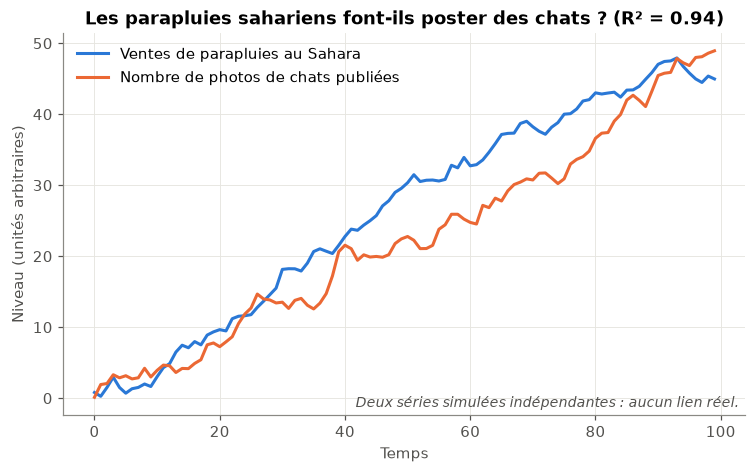

In [3]:
graphiques.figure_series_fallacieuses(marches, r2=regressions.loc[0, "R²"]);

En niveaux : R² énorme, p-value quasi nulle. Un lecteur pressé conclurait à un lien très fort.
Mais le Durbin-Watson est très faible (R² > DW : signal d'alarme classique de Granger & Newbold).

### Les séries sont-elles stationnaires ? (test ADF, H0 : racine unitaire)

In [4]:
analyse.tableau_adf(marches)

,Série,p-value ADF niveaux,p-value ADF différences
0,x,1.0000,0.0000
1,y,0.1225,0.0000


En niveaux, on ne rejette pas la racine unitaire : les séries ne sont pas stationnaires et les
statistiques usuelles de l'OLS ne sont pas valides. Les différences premières, elles, sont stationnaires.
En différences, le lien disparaît :

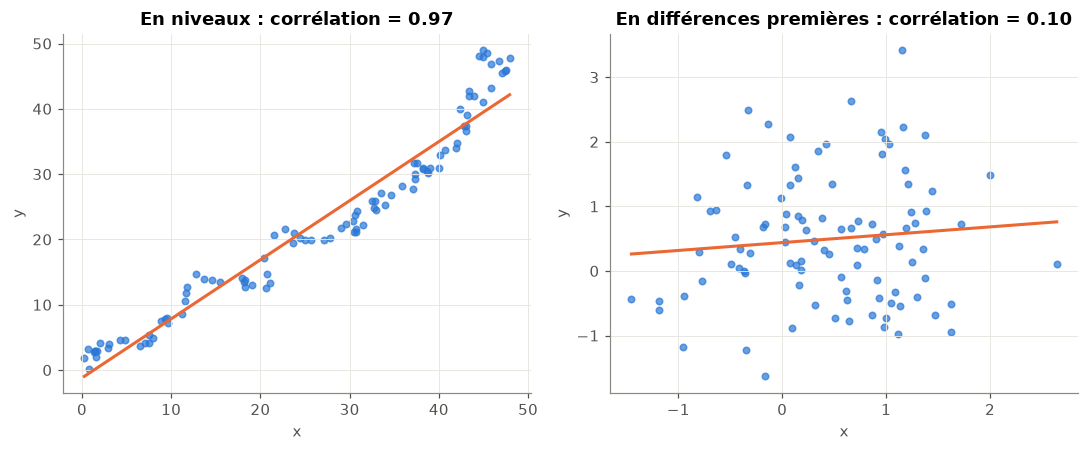

In [5]:
graphiques.figure_nuages_niveaux_differences(marches);

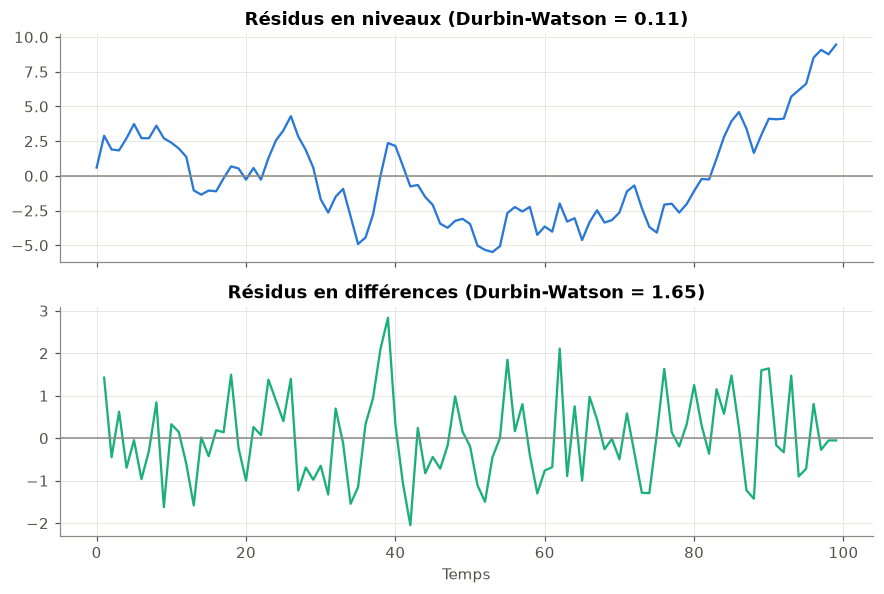

In [6]:
niv = analyse.regression_ols(marches["y"].values, marches["x"].values)
dif = analyse.regression_ols(marches["y"].diff().dropna().values, marches["x"].diff().dropna().values)
graphiques.figure_residus(niv["residus"], dif["residus"], niv["durbin_watson"], dif["durbin_watson"]);

### Monte Carlo : ce n'est pas un coup de malchance
On recommence 500 fois avec de nouvelles paires de séries indépendantes.

In [7]:
mc = analyse.monte_carlo_fallacieux(n_rep=500, n=100, derive=0.5, seed=0)
taux = analyse.taux_significatifs(mc)
pd.Series(taux, name="% significatifs à 5 %")

niveaux       100.0000
differences     4.2000
Name: % significatifs à 5 %, dtype: float64

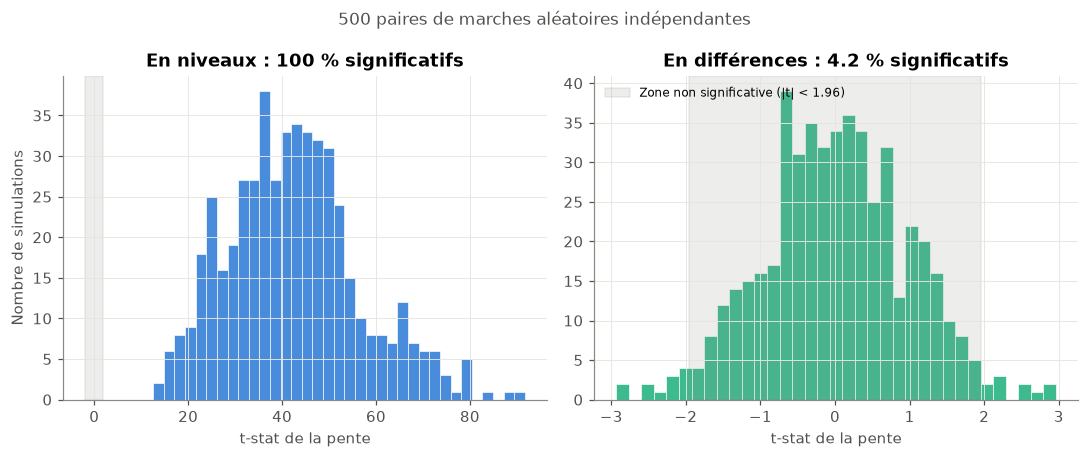

In [8]:
graphiques.figure_histogramme_tstats(mc, taux);

En différences, on retrouve à peu près les 5 % de faux positifs attendus. En niveaux, presque toutes les
régressions sont « significatives ».

### Et avec plus de données ?

In [9]:
tailles = [25, 50, 100, 200, 500, 1000]
taux_avec = analyse.taux_selon_n(tailles, derive=0.5, n_rep=300, seed=100)
taux_sans = analyse.taux_selon_n(tailles, derive=0.0, n_rep=300, seed=200)
pd.concat({"avec dérive": taux_avec.set_index("n"), "sans dérive": taux_sans.set_index("n")}, axis=1)

avec dérive             sans dérive            
         niveaux differences     niveaux differences
n                                                   
25       97.0000      6.3333     49.6667      6.3333
50      100.0000      6.6667     66.0000      5.3333
100     100.0000      4.6667     77.3333      4.3333
200     100.0000      5.0000     87.3333      7.0000
500     100.0000      5.3333     88.3333      6.6667
1000    100.0000      6.0000     92.6667      5.3333

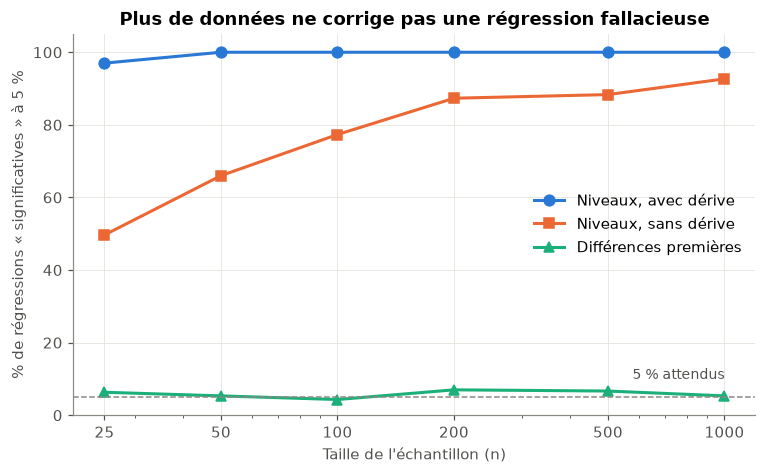

In [10]:
graphiques.figure_faux_positifs_selon_n(taux_avec, taux_sans);

Même sans dérive (le cas étudié par Granger & Newbold, 1974), le taux de faux positifs en niveaux
**augmente** avec $n$. Plus de données ne corrige pas une mauvaise spécification.

### Faut-il toujours différencier ? Non : la cointégration
Si deux séries non stationnaires suivent la **même tendance stochastique**, elles sont cointégrées : la
régression en niveaux décrit alors une vraie relation de long terme. Le test d'Engle-Granger
(H0 : pas de cointégration) permet de distinguer les deux situations.
Paire cointégrée simulée : $x_t = w_t + u_t$ et $y_t = 2 + 0.8\,w_t + v_t$, où $w_t$ est une marche aléatoire.

In [11]:
paire_cointegree = simulation.simuler_paire_cointegree(n=100, derive=0.5, seed=7)
analyse.tableau_cointegration(marches, paire_cointegree)

,Paire,Pente en niveaux,R²,p-value Engle-Granger
0,Paire indépendante (fallacieuse),0.9046,0.9404,0.8183
1,Paire cointégrée,0.7988,0.9834,0.0000


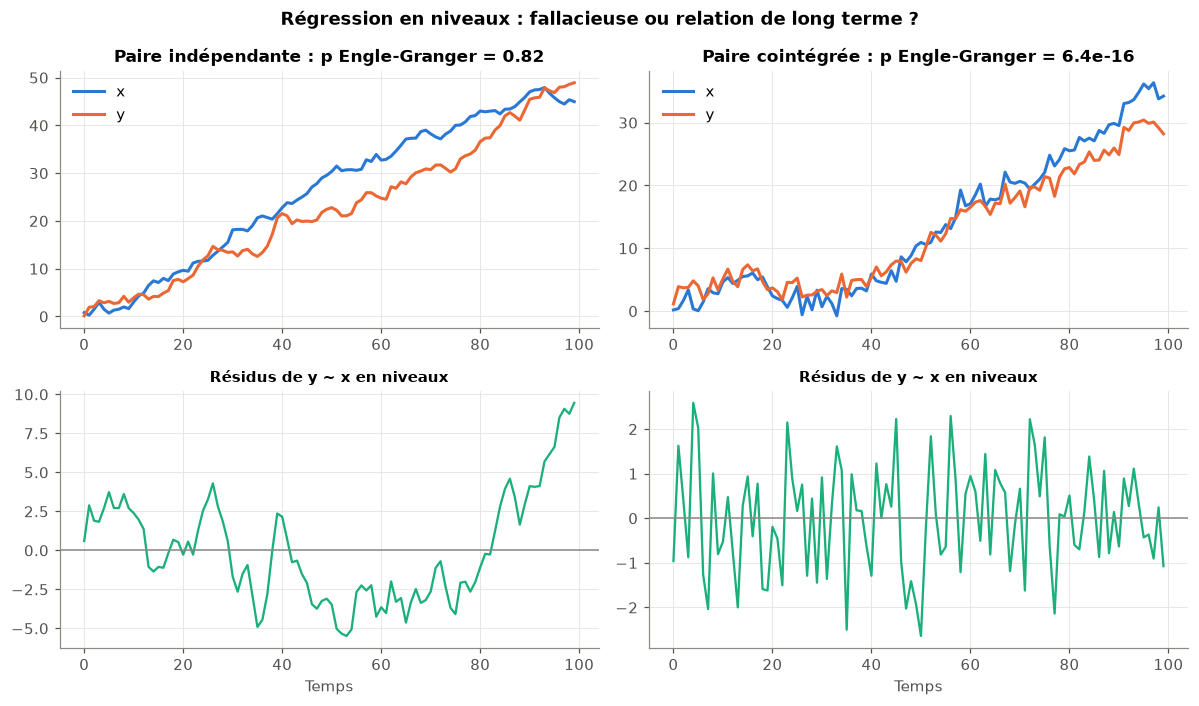

In [12]:
p_fall = analyse.test_cointegration(marches["y"].values, marches["x"].values)
p_coint = analyse.test_cointegration(paire_cointegree["y"].values, paire_cointegree["x"].values)
graphiques.figure_cointegration(marches, paire_cointegree, p_fall, p_coint);

Les résidus de la paire cointégrée reviennent toujours vers 0, ceux de la paire fallacieuse dérivent.
Le test est-il fiable ? Sur 300 paires de chaque type :

In [13]:
pd.Series(analyse.taux_rejet_cointegration(n_rep=300, n=100, seed=0), name="% déclarées cointégrées")

cointegrees     97.3333
independantes    9.6667
Name: % déclarées cointégrées, dtype: float64

Le test détecte presque toujours la cointégration, mais il déclare cointégrées environ 10 % des paires
indépendantes au lieu des 5 % attendus : avec $n = 100$ et des séries à dérive, ses valeurs critiques ne sont
qu'approximatives. Un test de cointégration aide, il ne garantit rien.

## Partie 2 : le confondeur (glaces, noyades et température)

Données simulées ($n = 5\,000$) :

- $\text{température} \sim N(20, 6)$
- $\text{glaces} = 2\,T + 0.05\,T^2 + \varepsilon_g$, avec $\varepsilon_g \sim N(0, 5)$
- $\text{noyades} = 0.3\,T + 0.01\,T^2 + \text{effet} \times \text{glaces} + \varepsilon_n$, avec $\varepsilon_n \sim N(0, 2)$

**L'effet vrai des glaces sur les noyades est nul.**

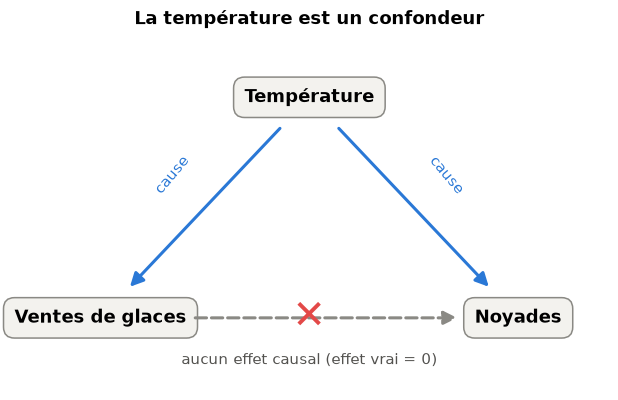

In [14]:
graphiques.figure_dag();

In [15]:
df = simulation.simuler_glaces_noyades(n=5000, effet=0.0, seed=123)
df.describe()

,temperature,glaces,noyades
count,5000.0000,5000.0000,5000.0000
mean,20.0318,61.9878,10.4036
std,6.0084,24.5579,4.6834
min,-1.3970,-2.9124,-3.7076
25%,15.9650,44.6189,7.0670
50%,20.0415,60.1062,10.1746
75%,24.1731,77.6208,13.4251
max,38.9772,151.7593,30.2123


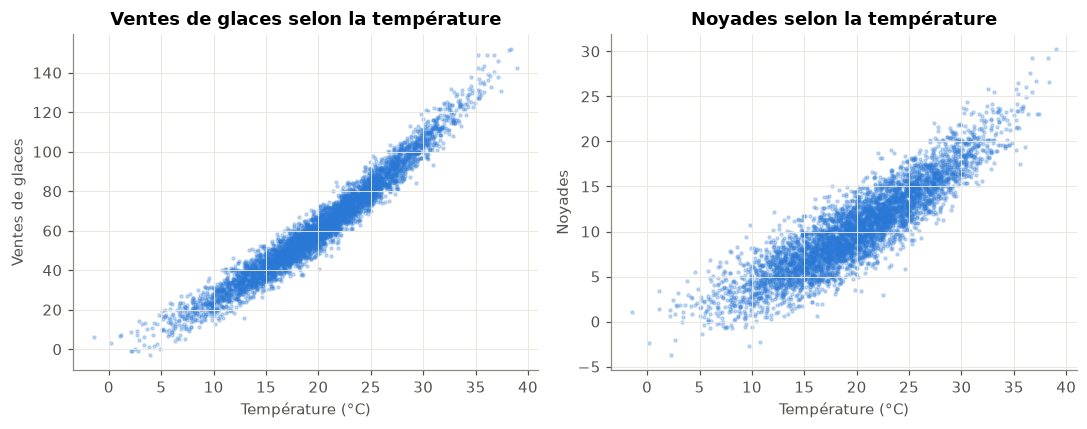

In [16]:
graphiques.figure_relations_temperature(df);

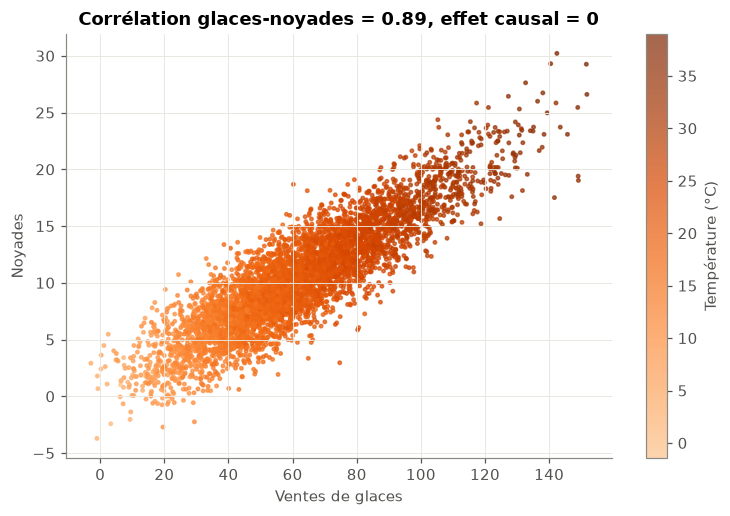

In [17]:
graphiques.figure_nuage_confondu(df);

Glaces et noyades sont très corrélées, uniquement parce qu'elles montent toutes les deux avec la température.

### Prédire : le Gradient Boosting naïf

In [18]:
gb_naif = analyse.effet_gradient_boosting(df, ["glaces"])
print(f"R² en validation croisée : {gb_naif['r2_cv']:.3f}")
print(f"Effet implicite d'une glace de plus : {gb_naif['effet']:.4f}")

R² en validation croisée : 0.784
Effet implicite d'une glace de plus : 0.1666


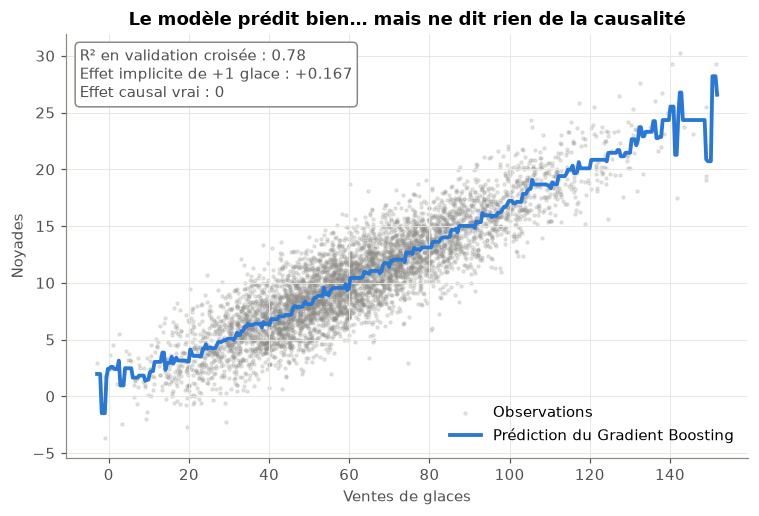

In [19]:
graphiques.figure_prediction_gb(df, gb_naif["modele"], gb_naif["r2_cv"], gb_naif["effet"]);

Le modèle **prédit bien** : connaître les ventes de glaces aide réellement à prévoir les noyades, puisque
les deux révèlent la température. Mais si on l'utilise pour répondre à « que se passe-t-il si on vend une glace
de plus ? », il répond environ +0.17 noyade, alors que la vraie réponse est 0.

### Expliquer : comparer des situations à température égale

In [20]:
analyse.pentes_par_tranche(df)

,tranche,temperature_min,temperature_max,pente
0,1,-1.3970,12.3192,0.1067
1,2,12.3199,14.9407,0.0261
2,3,14.9425,16.9054,0.0480
3,4,16.9075,18.5299,0.0109
4,5,18.5301,20.0407,0.0543
5,6,20.0424,21.5601,0.0222
6,7,21.5623,23.1789,0.0198
7,8,23.1845,25.1594,0.0114
8,9,25.1616,27.7694,0.0778
9,10,27.7706,38.9772,0.1521


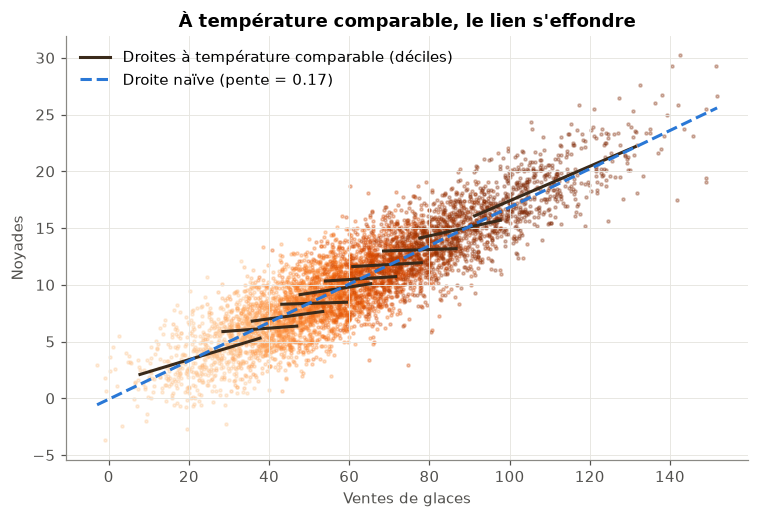

In [21]:
graphiques.figure_stratification(df);

Dans chaque tranche de température, la pente est bien plus faible que la pente naïve. Elle n'est pas
exactement nulle, parce que la température varie encore un peu à l'intérieur de chaque tranche (surtout aux
extrêmes). Pour éliminer complètement le biais, il faut contrôler la température de façon fine : c'est
ce que font l'OLS bien spécifié et le Double ML.

### Tableau comparatif (effet vrai = 0)

In [22]:
tableau_0 = analyse.tableau_comparatif(df, effet_vrai=0.0)
tableau_0

,Méthode,Effet estimé,IC 95 % bas,IC 95 % haut,Écart à la vraie valeur
0,Gradient Boosting naïf,0.1666,NaN,NaN,0.1666
1,OLS naïf,0.1691,0.1667,0.1716,0.1691
2,OLS + température + température²,0.0061,-0.0051,0.0173,0.0061
3,Double ML (forêts aléatoires),0.0036,-0.0079,0.0151,0.0036
4,Bonus : OLS + température (sans le carré),0.0468,0.0365,0.0570,0.0468
5,Bonus : Gradient Boosting + température,0.0155,NaN,NaN,0.0155


- Le **Gradient Boosting naïf** et l'**OLS naïf** trouvent environ 0.17 : c'est le biais de confusion.
  L'IC de l'OLS naïf est très étroit : une estimation peut être très précise et complètement fausse.
- L'**OLS avec la température et son carré** retrouve un effet proche de 0. Les deux lignes « bonus » sont là
  pour la discussion :
  - **sans le carré**, l'OLS reste biaisé (forme fonctionnelle fausse) ;
  - le **Gradient Boosting avec la température** se rapproche de 0. Ce n'est donc pas l'algorithme qui pose
    problème, c'est la question qu'on lui pose et les variables qu'on lui donne. Il n'a toutefois pas
    d'intervalle de confiance.
- Le **Double ML** retrouve un effet proche de 0 avec un IC à 95 % qui contient 0, sans qu'on ait à
  préciser la forme fonctionnelle de la température.

### Vérification : effet vrai = 0.5
Une méthode qui répondrait toujours « 0 » serait inutile. On vérifie que le Double ML retrouve aussi un effet non nul.

In [23]:
df_05 = simulation.simuler_glaces_noyades(n=5000, effet=0.5, seed=123)
tableau_05 = analyse.tableau_comparatif(df_05, effet_vrai=0.5)
tableau_05

,Méthode,Effet estimé,IC 95 % bas,IC 95 % haut,Écart à la vraie valeur
0,Gradient Boosting naïf,0.6629,NaN,NaN,0.1629
1,OLS naïf,0.6691,0.6667,0.6716,0.1691
2,OLS + température + température²,0.5061,0.4949,0.5173,0.0061
3,Double ML (forêts aléatoires),0.5000,0.4884,0.5115,-0.0000
4,Bonus : OLS + température (sans le carré),0.5468,0.5365,0.5570,0.0468
5,Bonus : Gradient Boosting + température,0.5045,NaN,NaN,0.0045


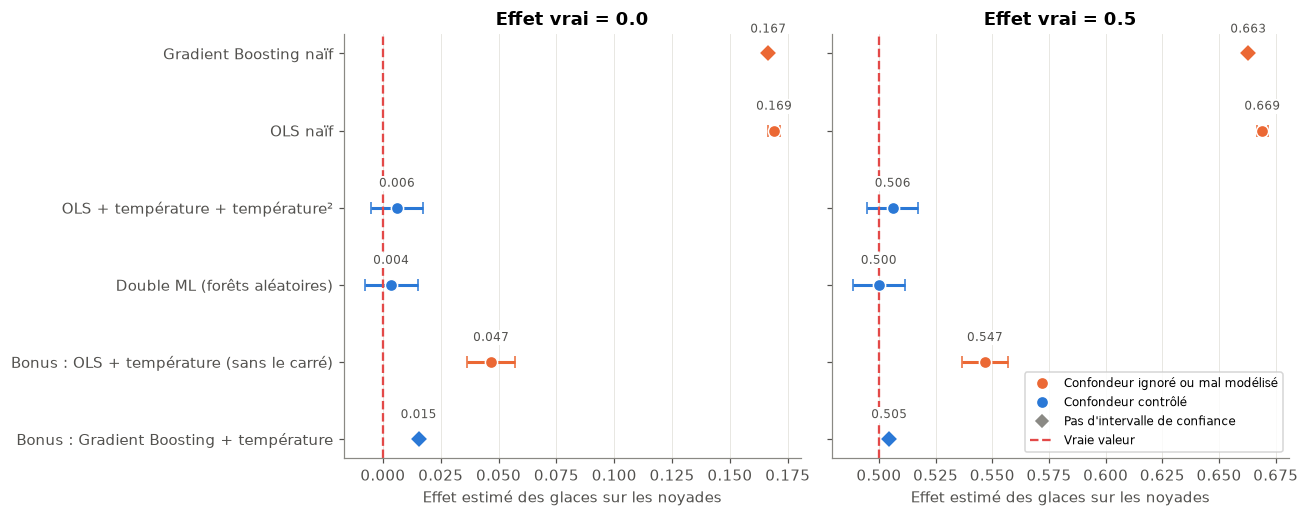

In [24]:
graphiques.figure_estimations(tableau_0, tableau_05);

## Partie 3 : robustesse et limites

### 3.1 Un seul jeu de données ne suffit pas : Monte Carlo des estimateurs
On répète simulation + estimation 100 fois. Un bon estimateur est sans biais en moyenne, et son IC à 95 %
doit contenir la vraie valeur dans environ 95 % des simulations (**couverture**).
(Calcul de quelques minutes : les forêts du Double ML ont ici 100 arbres au lieu de 200.)

In [25]:
mc_estimateurs = analyse.monte_carlo_estimateurs(n_rep=100, n=5000, effet=0.0)
resume_mc = analyse.resume_monte_carlo(mc_estimateurs, effet_vrai=0.0)
resume_mc

,n,methode,biais,ecart_type,largeur_ic,couverture
0,5000,OLS naïf,0.1680,0.0012,0.0049,0.0000
1,5000,OLS + T + T²,0.0008,0.0061,0.0222,96.0000
2,5000,OLS + T (sans le carré),0.0415,0.0053,0.0203,0.0000
3,5000,Double ML,0.0024,0.0066,0.0229,87.0000


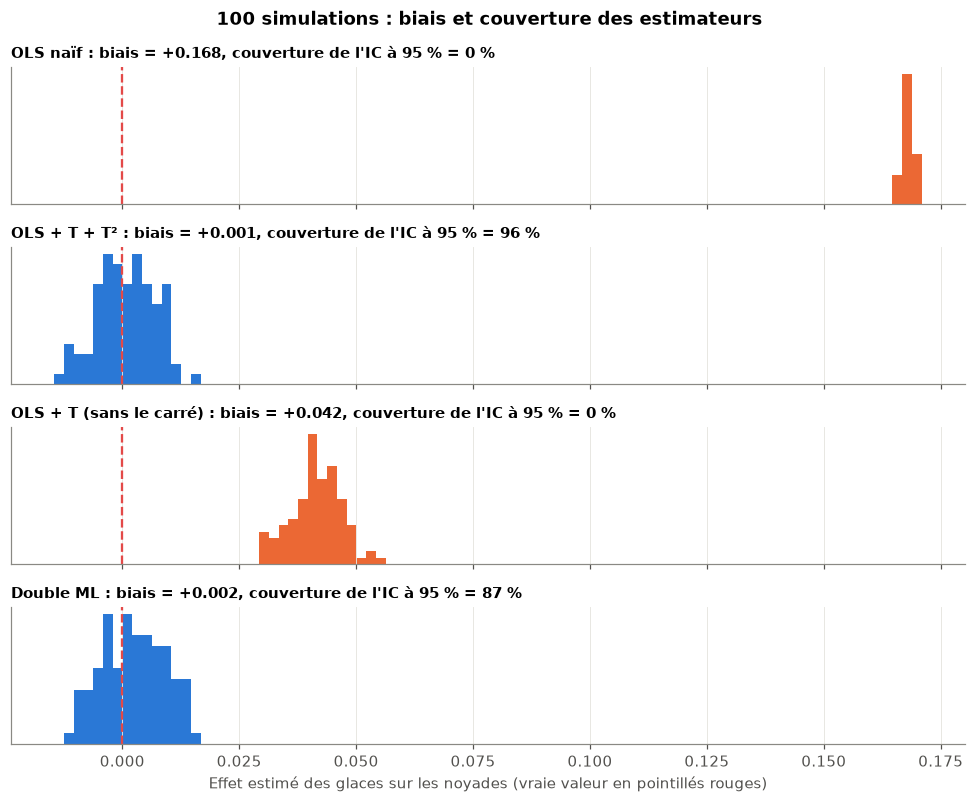

In [26]:
graphiques.figure_monte_carlo_estimateurs(mc_estimateurs, resume_mc);

- **OLS naïf** et **OLS sans le carré** : couverture de 0 %. À chaque simulation, l'IC est étroit autour d'une
  mauvaise valeur.
- **OLS + T + T²** : sans biais, couverture de 96 % (c'est exactement le vrai modèle).
- **Double ML** : biais moyen très faible (0.002), mais couverture de 87 %, un peu sous les 95 % annoncés. Les
  estimations varient un peu plus que ce qu'indique l'écart-type calculé par le Double ML : ses garanties sont
  asymptotiques, et les erreurs des forêts aléatoires ne sont pas totalement négligeables à $n = 5\,000$
  (voir `notebooks/05_brouillon_monte_carlo_estimateurs.ipynb`). Avec 100 simulations, cette couverture est
  connue à environ ± 3 points près.

### 3.2 Combien de données faut-il ?

In [27]:
mc_taille = analyse.monte_carlo_taille([200, 500, 1000, 2000, 5000], n_rep=50)
resume_taille = analyse.resume_monte_carlo(mc_taille, effet_vrai=0.0)
resume_taille[resume_taille["methode"].isin(["Double ML", "OLS + T + T²"])]

,n,methode,biais,ecart_type,largeur_ic,couverture
1,200,OLS + T + T²,0.0031,0.0242,0.1104,98.0000
3,200,Double ML,0.0527,0.0260,0.1180,54.0000
5,500,OLS + T + T²,-0.0008,0.0195,0.0703,94.0000
7,500,Double ML,0.0219,0.0243,0.0784,80.0000
9,1000,OLS + T + T²,0.0024,0.0126,0.0498,98.0000
11,1000,Double ML,0.0104,0.0137,0.0526,90.0000
13,2000,OLS + T + T²,-0.0011,0.0095,0.0352,90.0000
15,2000,Double ML,0.0037,0.0102,0.0376,96.0000
17,5000,OLS + T + T²,0.0006,0.0058,0.0222,94.0000
19,5000,Double ML,0.0025,0.0063,0.0226,92.0000


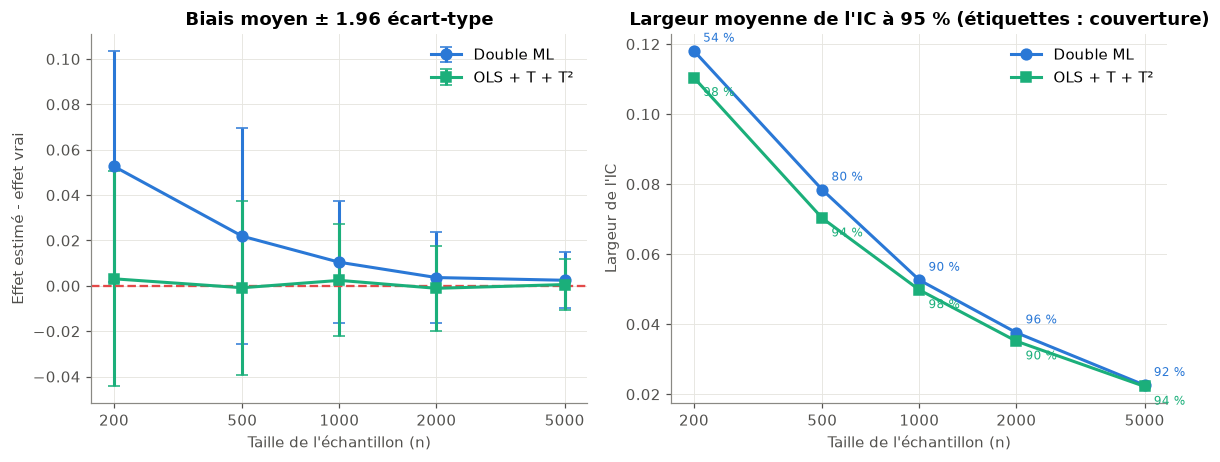

In [28]:
graphiques.figure_taille_echantillon(resume_taille);

L'OLS bien spécifié est fiable dès $n = 200$ : il connaît la bonne forme fonctionnelle. Le Double ML a besoin de
données : à $n = 200$, son biais est de 0.05 et la couverture tombe à 54 %. Il devient fiable vers $n = 2\,000$.
C'est le prix de la flexibilité : les forêts aléatoires doivent apprendre seules la forme de l'effet de la
température. (Avec 50 simulations par taille, les couvertures sont connues à environ ± 6 points près.)

### 3.3 Et si le confondeur est mal mesuré ?
On remplace la vraie température par une mesure bruitée, $T + \eta$ avec $\eta \sim N(0, \sigma)$ : par exemple
la température d'une station météo éloignée de la plage.

In [29]:
erreur = analyse.biais_erreur_mesure(df, sigmas=[0, 1, 2, 3, 4, 6, 10])
erreur

,sigma,dml,dml_ic_bas,dml_ic_haut,ols
0,0,0.0037,-0.0079,0.0152,0.0061
1,1,0.0730,0.0638,0.0822,0.0713
2,2,0.1245,0.1179,0.1311,0.1255
3,3,0.1439,0.1389,0.1490,0.1466
4,4,0.1548,0.1506,0.1591,0.1557
5,6,0.1638,0.1604,0.1672,0.1629
6,10,0.1663,0.1634,0.1692,0.1669


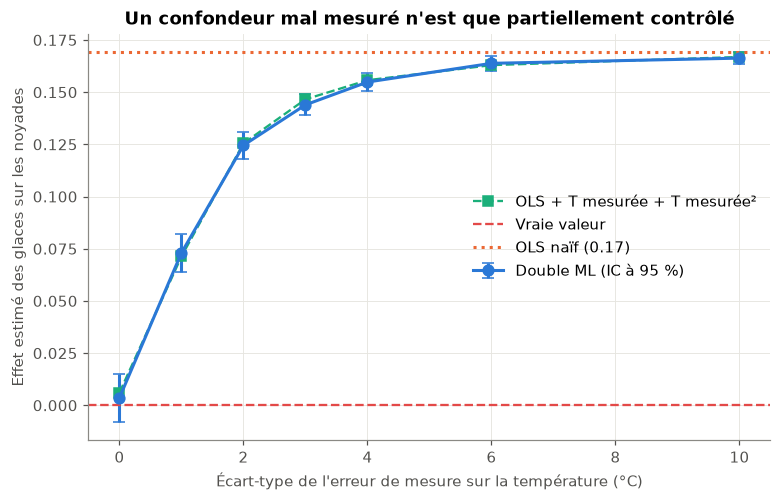

In [30]:
graphiques.figure_erreur_mesure(erreur, effet_naif=tableau_0.loc[1, "Effet estimé"]);

Le biais revient très vite : dès $\sigma = 1$ °C, l'effet estimé est d'environ 0.07 et l'IC du Double ML
n'inclut plus 0. Avec une très mauvaise mesure, on retombe sur l'estimation naïve. Le Double ML ne corrige
que la confusion due aux variables qu'on lui donne : un confondeur mal mesuré est un confondeur en partie
non observé.

### 3.4 L'importance des variables n'est pas un effet causal
Importance par permutation d'un Gradient Boosting : de combien baisse le R² (sur un échantillon test)
quand on mélange une variable ?

In [31]:
df_mesure = simulation.ajouter_temperature_mesuree(df, sigma=3)
df_05_mesure = simulation.ajouter_temperature_mesuree(df_05, sigma=3)
scenarios = {
    "Effet vrai = 0, température exacte": analyse.importances_permutation(df, ["glaces", "temperature"]),
    "Effet vrai = 0, température mesurée (σ = 3)": analyse.importances_permutation(df_mesure, ["glaces", "temp_mesuree"]),
    "Effet vrai = 0.5, température mesurée (σ = 3)": analyse.importances_permutation(df_05_mesure, ["glaces", "temp_mesuree"]),
}
pd.DataFrame(scenarios)

,"Effet vrai = 0, température exacte","Effet vrai = 0, température mesurée (σ = 3)","Effet vrai = 0.5, température mesurée (σ = 3)"
glaces,0.0331,1.1974,1.8309
temp_mesuree,NaN,0.0373,0.0038
temperature,1.3916,NaN,NaN


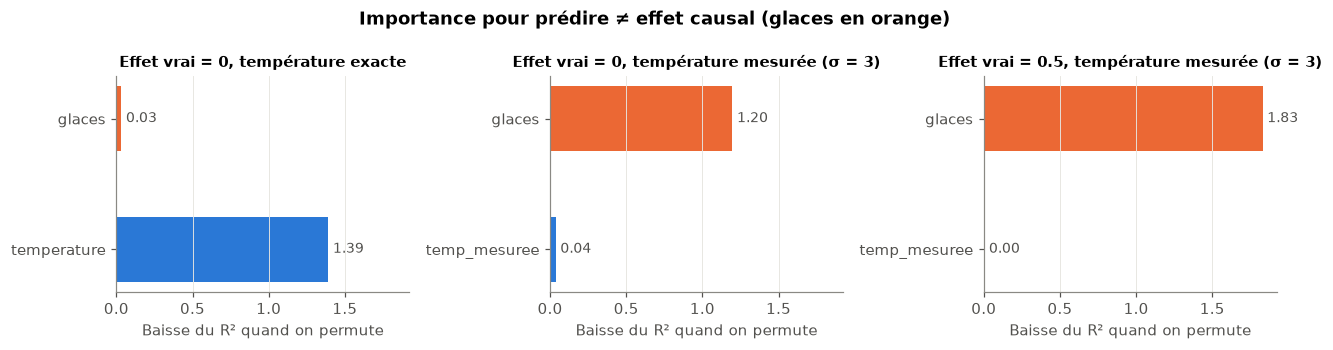

In [32]:
graphiques.figure_importances(scenarios);

- Avec la vraie température, les glaces n'apportent presque rien : importance faible.
- Avec une température mal mesurée, les glaces deviennent la variable **la plus importante**, alors que leur
  effet causal est nul : elles servent de meilleur thermomètre que le thermomètre.
- Leur importance est élevée aussi quand l'effet vrai vaut 0.5 : l'importance ne permet pas de distinguer un
  effet nul d'un effet réel. Elle mesure l'utilité pour **prédire**, pas l'effet d'une intervention.

### 3.5 Contrôler plus n'est pas contrôler mieux : le collider
On ajoute le nombre d'articles de presse sur « l'été dangereux », causé à la fois par les glaces et les
noyades : $\text{presse} = 0.2\,\text{glaces} + 2\,\text{noyades} + N(0, 3)$.

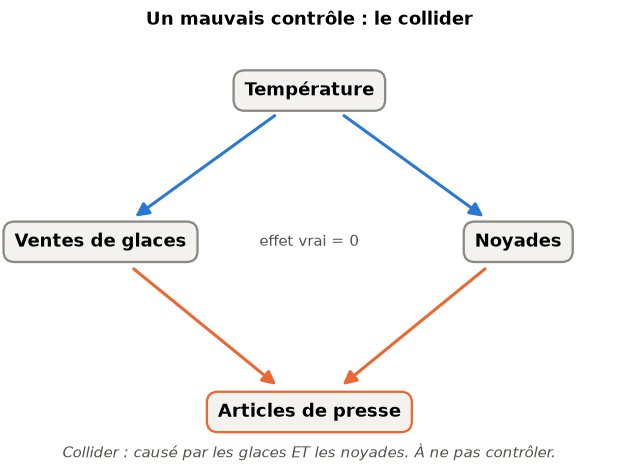

In [33]:
graphiques.figure_dag_collider();

In [34]:
collider_0 = analyse.tableau_mauvais_controle(df, effet_vrai=0.0)
collider_05 = analyse.tableau_mauvais_controle(df_05, effet_vrai=0.5)
pd.concat({"effet vrai = 0": collider_0.set_index("Méthode"), "effet vrai = 0.5": collider_05.set_index("Méthode")})

Effet estimé  IC 95 % bas  \
                 Méthode                                             
effet vrai = 0   OLS + T + T²                  0.0061      -0.0051   
                 OLS + T + T² + presse        -0.0633      -0.0702   
                 Double ML (T)                 0.0036      -0.0079   
                 Double ML (T + presse)       -0.0625      -0.0695   
effet vrai = 0.5 OLS + T + T²                  0.5061       0.4949   
                 OLS + T + T² + presse         0.1164       0.1058   
                 Double ML (T)                 0.5000       0.4884   
                 Double ML (T + presse)        0.1220       0.1109   

                                         IC 95 % haut  Écart à la vraie valeur  
                 Méthode                                                        
effet vrai = 0   OLS + T + T²                  0.0173                   0.0061  
                 OLS + T + T² + presse        -0.0564                  -0.0633  
                 Double ML (T)                 0.0151                   0.0036  
                 Double ML (T + presse)       -0.0555                  -0.0625  
effet vrai = 0.5 OLS + T + T²                  0.5173                   0.0061  
                 OLS + T + T² + presse         0.1270                  -0.3836  
                 Double ML (T)                 0.5115                  -0.0000  
                 Double ML (T + presse)        0.1332                  -0.3780

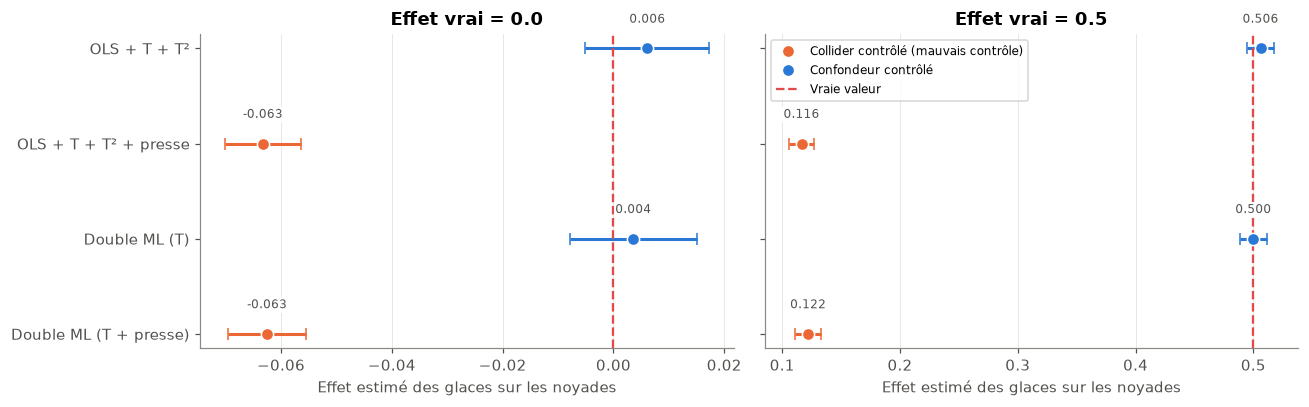

In [35]:
graphiques.figure_estimations(collider_0, collider_05, nom_fichier="p3_06_mauvais_controle.png",
                              mots_biaises=("presse",), legende_biais="Collider contrôlé (mauvais contrôle)");

Ajouter la presse aux contrôles **crée** un biais là où l'estimation était juste : environ -0.06 quand l'effet
vrai est nul, et l'effet de 0.5 tombe à environ 0.12. Intuition : à nombre d'articles donné, si les ventes de
glaces sont élevées, c'est qu'il y a eu moins de noyades pour « expliquer » la presse. Le Double ML n'y échappe
pas : il fait confiance au choix des contrôles. Le choix des variables vient d'un raisonnement causal
(le schéma), pas de l'algorithme.

## Conclusion

- **Prédire ≠ expliquer.** Un bon R² ou une forte importance de variable ne disent rien de l'effet causal.
  Le modèle naïf n'est pas « mauvais » : il répond très bien à une autre question.
- **Identifier le confondeur est l'étape décisive.** Une fois la température prise en compte, l'OLS (bien
  spécifié) et le Double ML retrouvent le vrai effet, en moyenne et avec des IC fiables.
- **Le Double ML** combine la flexibilité du machine learning (pas besoin de connaître la forme exacte de
  l'effet de la température) et l'inférence de l'économétrie (un intervalle de confiance valide).
- **Mais il ne fait pas de miracle :** un confondeur mal mesuré laisse un biais, et un mauvais contrôle
  (collider) en crée un. Dans la vraie vie, on ne sait jamais avec certitude si tous les confondeurs sont
  observés : la qualité de l'analyse causale dépend d'abord du raisonnement sur le schéma causal.